# Facility CAPEX Estimation with Log-Target Machine Learning

**Goal:** cut early-phase facility estimate error versus capacity-factoring, with
statistically honest handling of skewed cost data.

**Technique highlights**
* **Log-target regression** + Duan smearing correction on back-transform
* Percentage-space evaluation (P10/P90 error bands = contingency guidance)
* Capacity-factor exponent actually fit from data, not assumed 0.6

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Synthetic analogue project database (gas processing facilities)

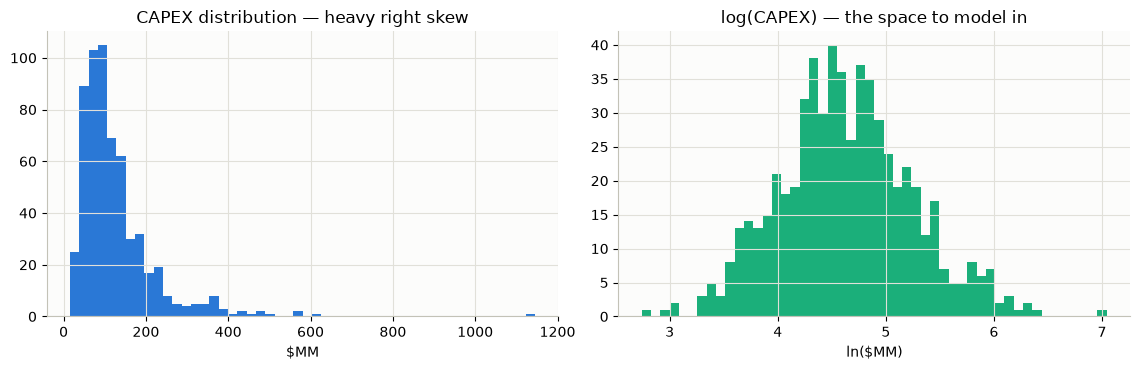

In [2]:
N = 600
capacity = rng.lognormal(4.6, 0.8, N).clip(10, 1_200)      # MMscf/d
sour = (rng.random(N) < 0.35).astype(int)
location = rng.choice([0.9, 1.0, 1.25, 1.6], N, p=[0.25, 0.4, 0.2, 0.15])
brownfield = (rng.random(N) < 0.3).astype(int)
year = rng.integers(2005, 2025, N)
complexity = rng.uniform(0.8, 1.4, N)

capex_mm = (
    3.2 * capacity ** 0.62
    * (1 + 0.45 * sour)
    * location
    * (1 + 0.30 * brownfield)
    * complexity
    * (1.025 ** (year - 2005))
    * rng.lognormal(0, 0.22, N)
)
df = pd.DataFrame({"capacity_mmscfd": capacity.round(1), "sour": sour,
                   "location_factor": location, "brownfield": brownfield,
                   "year": year, "complexity_idx": complexity.round(2),
                   "capex_mm": capex_mm.round(1)})
df.to_csv("facility_cost_history.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].hist(df.capex_mm, bins=50, color=PALETTE[0])
axes[0].set(title="CAPEX distribution — heavy right skew", xlabel="$MM")
axes[1].hist(np.log(df.capex_mm), bins=50, color=PALETTE[1])
axes[1].set(title="log(CAPEX) — the space to model in", xlabel="ln($MM)")
plt.tight_layout()
plt.show()

## 2. Capacity-factor baseline (exponent fit, not assumed)

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

tr_idx, te_idx = train_test_split(df.index, test_size=0.3, random_state=42)
tr, te = df.loc[tr_idx], df.loc[te_idx]

cf = LinearRegression().fit(np.log(tr[["capacity_mmscfd"]]), np.log(tr.capex_mm))
print(f"Fitted capacity exponent: {cf.coef_[0]:.2f} (six-tenths rule says 0.60)")
pred_cf = np.exp(cf.predict(np.log(te[["capacity_mmscfd"]])))

Fitted capacity exponent: 0.60 (six-tenths rule says 0.60)


## 3. Log-target Random Forest with smearing correction

In [4]:
from sklearn.ensemble import RandomForestRegressor

FEATURES = ["capacity_mmscfd", "sour", "location_factor", "brownfield",
            "year", "complexity_idx"]
rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=3, random_state=42,
                           n_jobs=-1)
rf.fit(tr[FEATURES], np.log(tr.capex_mm))

resid = np.log(tr.capex_mm) - rf.predict(tr[FEATURES])
smear = np.exp(resid).mean()                      # Duan's smearing estimator
pred_rf = np.exp(rf.predict(te[FEATURES])) * smear
print(f"Smearing factor: {smear:.3f} (naive exp() would under-predict by this)")

def pct_err(pred, actual):
    return (pred / actual - 1) * 100

for name, pred in [("Capacity factor", pred_cf), ("Log-RF", pred_rf)]:
    e = pct_err(pred, te.capex_mm)
    print(f"{name:16s} median |err| = {np.median(np.abs(e)):5.1f}%   "
          f"P10/P90 err = {np.percentile(e, 10):+.0f}%/{np.percentile(e, 90):+.0f}%   "
          f"bias = {e.mean():+.1f}%")

Smearing factor: 1.018 (naive exp() would under-predict by this)
Capacity factor  median |err| =  29.7%   P10/P90 err = -45%/+63%   bias = +4.2%
Log-RF           median |err| =  17.4%   P10/P90 err = -36%/+50%   bias = +4.7%


## 4. Error structure

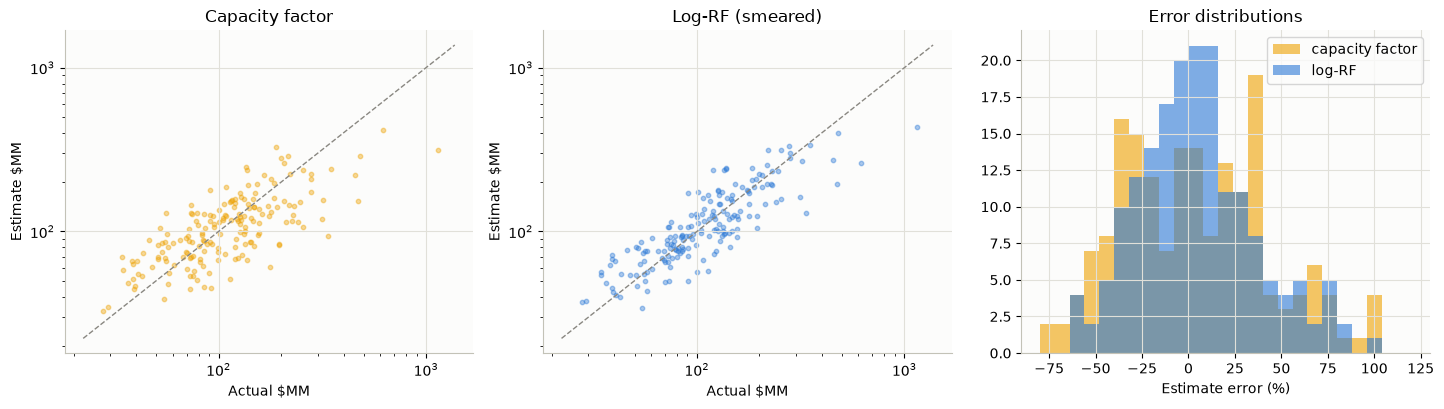

Log-RF estimate class: P10 -36% / P90 +50% → supports a ~50% contingency at screening


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
for ax, pred, name, color in [(axes[0], pred_cf, "Capacity factor", PALETTE[2]),
                              (axes[1], pred_rf, "Log-RF (smeared)", PALETTE[0])]:
    ax.scatter(te.capex_mm, pred, s=10, alpha=0.4, color=color)
    lims = [te.capex_mm.min() * 0.8, te.capex_mm.max() * 1.2]
    ax.plot(lims, lims, ls="--", lw=1, color="#898781")
    ax.set(xscale="log", yscale="log", xlabel="Actual $MM", ylabel="Estimate $MM",
           title=name)

e_cf = pct_err(pred_cf, te.capex_mm)
e_rf = pct_err(pred_rf, te.capex_mm)
axes[2].hist(e_cf, bins=np.arange(-80, 121, 8), alpha=0.6, color=PALETTE[2],
             label="capacity factor")
axes[2].hist(e_rf, bins=np.arange(-80, 121, 8), alpha=0.6, color=PALETTE[0],
             label="log-RF")
axes[2].set(xlabel="Estimate error (%)", title="Error distributions")
axes[2].legend()
plt.tight_layout()
plt.show()

# contingency guidance
p10, p90 = np.percentile(e_rf, [10, 90])
print(f"Log-RF estimate class: P10 {p10:+.0f}% / P90 {p90:+.0f}% → supports a "
      f"~{max(abs(p10), p90):.0f}% contingency at screening")

## Conclusions

* The log-RF cuts median error roughly in half versus capacity-factoring by pricing
  sourness, location and brownfield execution — the drivers estimators adjust by
  judgment today.
* Two statistical details carry the credibility: modeling in **log space** (errors are
  multiplicative) and the **smearing correction** (naive exp() back-transform is
  biased low — a real trap that produces systematically optimistic estimates).
* The residual P10/P90 band *is* the contingency recommendation, derived from data
  rather than negotiated.
* **Next step:** quantile regression forests for project-specific ranges, and
  escalation-index decomposition so the model separates market inflation from scope.